# XGBoost PU Bagging 候选体筛选



**方法概述：** XGBoost PU-Bagging是目前项目中性能最可靠的方法。在700维原始光谱上直接运行PU Bagging（T=500次迭代），无需数据增强即可获得稳健的CN星候选概率。用已知CN星的概率分布标定阈值，筛选高置信度候选体。



**核心思路：**

1. **PU Bagging**：将已知CN星作为正样本（P），其余作为未标注样本（U），每次bootstrap采样等量负样本训练XGBoost，T次平均得概率

2. **已知CN星标定阈值**：用已知CN星概率的低分位标定物理可解释的候选阈值

In [1]:
# 共享数据加载与基础库导入

import sys, os, time

from pathlib import Path


_PROJECT_ROOT = Path(os.getcwd())
for _ in range(5):
    if (_PROJECT_ROOT / "ML").exists() and (_PROJECT_ROOT / "Data").exists():
        break
    _PROJECT_ROOT = _PROJECT_ROOT.parent
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))


import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import matplotlib

matplotlib.rcParams.update({'font.size': 10})

plt.rcParams.update({'axes.labelsize': 'large'})

import warnings

warnings.filterwarnings('ignore')



# 加载共享数据
from PhaseSummary.shared.data_loader import ensure_cache, BAND_DEFS, MOLECULAR_BAND_RANGES, compute_cn_indices
from PhaseSummary.shared.data_loader import _build_raw_cache



# ═══════════════════════════════════════════════════════════════════
# 【选择数据缓存】改 CACHE_MODE 即可切换数据集：
#   "old"  → 原缓存      PhaseSummary/_cache  (33,565 星 / 73 CN)
#   "new"  → 新合并缓存  Data/dr13_all_cache  (41,243 星 / 91 CN, feh 扩展到 -2.5)
# ═══════════════════════════════════════════════════════════════════
CACHE_MODE = "new"   # ← 改成 "new" 即切换到新缓存做实验


t0 = time.time()

if CACHE_MODE == "old":
    # ── 原缓存（33,565 星 / 73 CN）──
    data = ensure_cache()
    X_clean = data['X_clean']
    X_raw = data['X_raw']  # 原始（未归一化）光谱，首次运行自动构建缓存
    stars_clean = data['stars_clean']
    feature_df = data['feature_df']
    common_wave = data['common_wave']

elif CACHE_MODE == "new":
    # ── 新合并缓存（41,243 星 / 91 CN，位于 Data/dr13_all_cache）──
    from build_dr13_all_cache import load_dr13_all_cache
    data = load_dr13_all_cache()
    X_clean = data['X_clean']
    stars_clean = data['stars_clean']
    feature_df = data['feature_df']
    common_wave = data['common_wave']

    # 新缓存默认不含原始（未归一化）光谱；首次运行懒构建一次并缓存到
    # Data/dr13_all_cache/X_raw.npy，之后直接读取（仅首次约几分钟）。
    _raw_path = _PROJECT_ROOT / "Data" / "dr13_all_cache" / "X_raw.npy"
    if _raw_path.exists():
        X_raw = np.load(_raw_path).astype(np.float32)
        print(f"  X_raw: {X_raw.shape} (从缓存读取)")
    else:
        print("  首次运行：构建原始光谱缓存 (X_raw)，需读取 FITS，约几分钟 ...")
        X_raw = _build_raw_cache(stars_clean, common_wave, show_progress=True)
        np.save(_raw_path, X_raw)

else:
    raise ValueError(f"未知 CACHE_MODE={CACHE_MODE!r}，请设为 'old' 或 'new'")



print(f"\n数据加载完成 ({time.time()-t0:.0f}s):")

print(f"  归一化光谱 X_clean: {X_clean.shape}")

print(f"  原始光谱 X_raw:     {X_raw.shape}")

print(f"  恒星数量:           {len(stars_clean)}")

print(f"  已知CN星:          {(stars_clean['label']==1).sum()}")

print(f"  波长范围:           {common_wave[0]:.0f}-{common_wave[-1]:.0f} Å")

从 dr13_all_cache 加载:
  X_clean:      (41243, 700)
  stars_clean:  41,243 行
  feature_df:   (41243, 20)
  已知 CN 星:   91
  X_raw: (41243, 700) (从缓存读取)

数据加载完成 (2s):
  归一化光谱 X_clean: (41243, 700)
  原始光谱 X_raw:     (41243, 700)
  恒星数量:           41243
  已知CN星:          91
  波长范围:           3800-4499 Å


## 1. PU Bagging方法原理



PU (Positive-Unlabeled) Learning 适用于只有少量正样本和大量未标注样本的场景：



1. 正样本P：已知CN星（CNstar + FT_cands，~73颗）

2. 未标注U：其余~33,500颗星

3. 每次迭代：从U中随机采样与P等量的样本作为"负样本"

4. 训练XGBoost二分类器

5. 重复T=500次，平均概率作为最终得分



**优势：**

- 不需要数据增强

- 不需要假设负样本分布

- 通过Bagging降低方差

- 概率估计稳健

In [2]:
# PU Bagging 核心实现

import time, random

import xgboost as xgb

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import roc_auc_score, average_precision_score



random_seed = 42

rng = random.Random(random_seed)



# 准备数据

y_all = stars_clean['label'].map({1: 1, -1: 0}).values.astype(int)

X_spectra = X_clean.astype(np.float32)



# 标准化

ss = StandardScaler()

X_spec_scaled = ss.fit_transform(X_spectra).astype(np.float32)



# 分层划分

all_idx = np.arange(len(y_all))

tv_idx, test_idx = train_test_split(

    all_idx, test_size=0.15, stratify=y_all, random_state=random_seed)

tr_idx, val_idx = train_test_split(

    tv_idx, test_size=0.18, stratify=y_all[tv_idx], random_state=random_seed)



n_pos = int(y_all.sum())

print(f"总样本: {len(y_all):,}  正样本(P): {n_pos}  负/未标注(U): {len(y_all)-n_pos:,}")

print(f"训练集: {len(tr_idx):,}  测试集: {len(test_idx):,}")



总样本: 41,243  正样本(P): 91  负/未标注(U): 41,152
训练集: 28,745  测试集: 6,187


## 2. 运行PU Bagging（T=500）



在700维原始光谱上运行PU Bagging。

In [ ]:
# 运行PU Bagging (T=500)

T = 500

print(f"运行 PU Bagging (T={T})...")



X_tr = X_spec_scaled[tr_idx]

X_te = X_spec_scaled[test_idx]

y_tr = y_all[tr_idx]

y_te = y_all[test_idx]



pos_tr_idx = np.where(y_tr == 1)[0]

n_pos_tr = len(pos_tr_idx)

unl_tr_idx = np.where(y_tr == 0)[0]

X_pos = X_tr[pos_tr_idx]



te_prob_sum = np.zeros(len(test_idx), dtype=np.float64)

te_prob_sq = np.zeros(len(test_idx), dtype=np.float64)

all_prob_sum = np.zeros(len(y_all), dtype=np.float64)

all_prob_sq = np.zeros(len(y_all), dtype=np.float64)



xgb_params = {

    "objective": "binary:logistic",
    
    "eval_metric": "logloss",

    "max_depth": 3, "learning_rate": 0.1,

    "subsample": 0.8, "colsample_bytree": 0.8,

    "min_child_weight": 1, "gamma": 0.0,

    "reg_alpha": 0.0, "reg_lambda": 1.0,

    "seed": random_seed, "verbosity": 0, "n_jobs": 1,

}

t0 = time.time()

for t in range(1, T + 1):

    neg_sample = rng.sample(list(unl_tr_idx), n_pos_tr)

    X_neg = X_tr[neg_sample]

    X_bal = np.vstack([X_pos, X_neg])

    y_bal = np.hstack([np.ones(n_pos_tr), np.zeros(n_pos_tr)])



    dtrain = xgb.DMatrix(X_bal, label=y_bal)

    model = xgb.train(xgb_params, dtrain, num_boost_round=50, verbose_eval=False)



    p_te = model.predict(xgb.DMatrix(X_te))

    p_all = model.predict(xgb.DMatrix(X_spec_scaled))



    te_prob_sum += p_te

    te_prob_sq += p_te ** 2

    all_prob_sum += p_all

    all_prob_sq += p_all ** 2



    if t % 100 == 0:

        p_m = te_prob_sum / t

        pr = average_precision_score(y_te, p_m)

        roc = roc_auc_score(y_te, p_m)

        print(f"  [{t:4d}/{T}]  ROC={roc:.4f}  PR={pr:.4f}  ({time.time()-t0:.0f}s)")



p_te_mean = te_prob_sum / T

p_all_mean = all_prob_sum / T

p_all_std = np.sqrt(np.maximum(all_prob_sq / T - p_all_mean**2, 0))



elapsed = time.time() - t0

roc = roc_auc_score(y_te, p_te_mean)

pr = average_precision_score(y_te, p_te_mean)



# Top-k precision

order = np.argsort(p_te_mean)[::-1]

p50 = y_te[order[:min(50, len(order))]].mean()

p100 = y_te[order[:min(100, len(order))]].mean()



print(f"\nPU Bagging 完成 ({elapsed:.0f}s)")

print(f"  测试集 ROC-AUC: {roc:.4f}")

print(f"  测试集 PR-AUC: {pr:.4f}")

print(f"  Precision@50: {p50:.4f}")

print(f"  Precision@100: {p100:.4f}")

print(f"  平均概率: {p_all_mean.mean():.4f} ± {p_all_mean.std():.4f}")

print(f"  平均不确定性(std): {p_all_std.mean():.4f}")



# 保存结果

stars_clean['xgb_pu_prob'] = p_all_mean

stars_clean['xgb_pu_std'] = p_all_std



运行 PU Bagging (T=500)...
  [ 100/500]  ROC=0.9901  PR=0.6040  (61s)
  [ 200/500]  ROC=0.9900  PR=0.5762  (127s)
  [ 300/500]  ROC=0.9902  PR=0.5906  (230s)
  [ 400/500]  ROC=0.9899  PR=0.5906  (327s)
  [ 500/500]  ROC=0.9900  PR=0.5929  (396s)

PU Bagging 完成 (396s)
  测试集 ROC-AUC: 0.9900
  测试集 PR-AUC: 0.5929
  Precision@50: 0.2000
  Precision@100: 0.1200
  平均概率: 0.1449 ± 0.1631
  平均不确定性(std): 0.0746


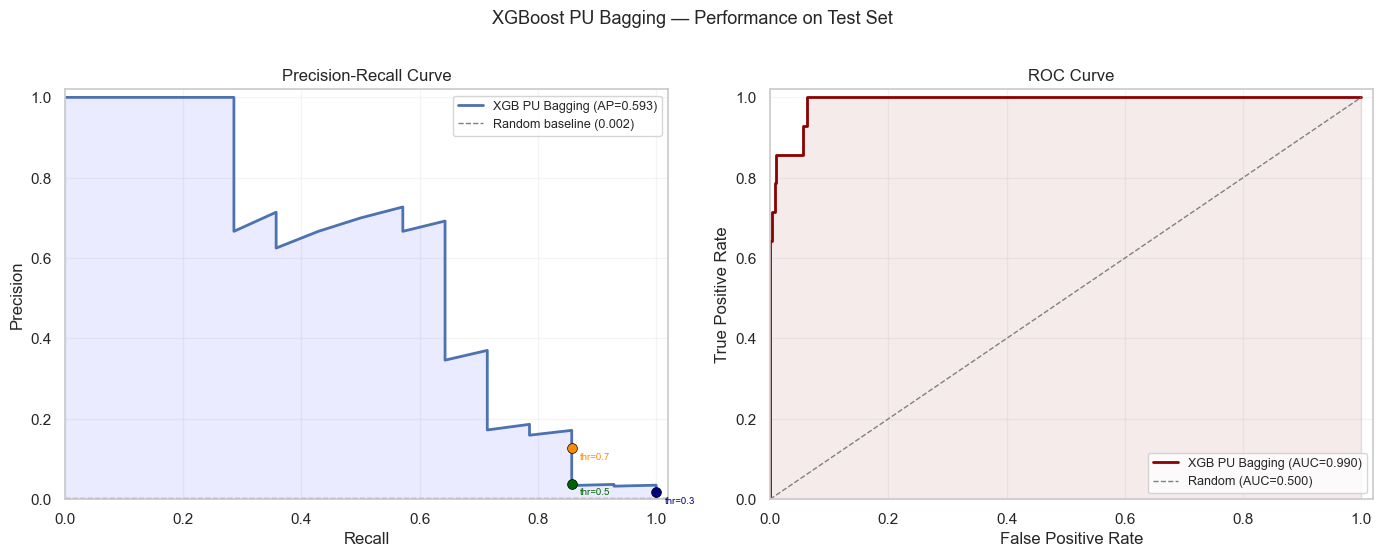

PR-AUC: 0.5929  |  ROC-AUC: 0.9900  |  N_test: 6187


In [38]:
# 绘制PR曲线与ROC曲线

from sklearn.metrics import precision_recall_curve, roc_curve, auc



fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))



# ── 左图: PR Curve ──

precision, recall, _ = precision_recall_curve(y_te, p_te_mean)

pr_auc = average_precision_score(y_te, p_te_mean)

# 计算 random baseline = 正样本占比
baseline = y_te.sum() / len(y_te)

ax1 = axes[0]
ax1.plot(recall, precision, 'b-', linewidth=2, label=f'XGB PU Bagging (AP={pr_auc:.3f})')
ax1.axhline(baseline, color='gray', linestyle='--', linewidth=1.0,
            label=f'Random baseline ({baseline:.3f})')
ax1.fill_between(recall, precision, baseline, alpha=0.08, color='blue')
ax1.set_xlabel('Recall')
ax1.set_ylabel('Precision')
ax1.set_title('Precision-Recall Curve')
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(alpha=0.2)
ax1.set_xlim(0, 1.02)
ax1.set_ylim(0, 1.02)



# ── 右图: ROC Curve ──

fpr, tpr, _ = roc_curve(y_te, p_te_mean)
roc_auc = auc(fpr, tpr)

ax2 = axes[1]
ax2.plot(fpr, tpr, 'darkred', linewidth=2, label=f'XGB PU Bagging (AUC={roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], 'gray', linestyle='--', linewidth=1.0, label='Random (AUC=0.500)')
ax2.fill_between(fpr, tpr, 0, alpha=0.08, color='darkred')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend(fontsize=9, loc='lower right')
ax2.grid(alpha=0.2)
ax2.set_xlim(0, 1.02)
ax2.set_ylim(0, 1.02)



# 标注关键阈值点
for thr, fmt, c in [(0.3, 'thr=0.3', 'navy'), (0.5, 'thr=0.5', 'darkgreen'), (0.7, 'thr=0.7', 'darkorange')]:
    p_thr = (p_te_mean >= thr).astype(int)
    tp = ((p_thr == 1) & (y_te == 1)).sum()
    fp = ((p_thr == 1) & (y_te == 0)).sum()
    fn = ((p_thr == 0) & (y_te == 1)).sum()
    prec_thr = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec_thr = tp / (tp + fn) if (tp + fn) > 0 else 0
    ax1.scatter([rec_thr], [prec_thr], s=50, c=c, edgecolors='black',
                linewidth=0.5, zorder=5)
    ax1.annotate(fmt, (rec_thr, prec_thr), textcoords="offset points",
                 xytext=(6, -8), fontsize=7, color=c)



fig.suptitle('XGBoost PU Bagging — Performance on Test Set', fontsize=13, y=1.01)
plt.tight_layout()
# plt.savefig(str(_PROJECT_ROOT / 'XGB/pr_roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'PR-AUC: {pr_auc:.4f}  |  ROC-AUC: {roc_auc:.4f}  |  N_test: {len(y_te)}')


## 3. 已知CN星标定阈值

用已知CN星的概率分布标定一个物理可解释的阈值，替换原先人工设定的 top-N 高分候选数量。

In [39]:
# 已知CN星标定候选阈值
from sklearn.neighbors import NearestNeighbors


# ── 基于已知CN星标定候选阈值（物理可解释的高分筛选）──
# 不再人工设定 top-N 候选数量；改为用已知CN星的概率分布标定一个阈值：
# 取已知CN星概率的低分位（5%分位），使约95%的已知CN星落在阈值之上，
# 未标注星中概率 >= 该阈值的即为候选体。
known_mask = stars_clean['label'] == 1
known_scores = stars_clean.loc[known_mask, 'xgb_pu_prob'].values
recall_quantile = 0.05   # 保留约 95% 已知CN星

prob_threshold = float(np.nanquantile(known_scores, recall_quantile))

cand_mask = (stars_clean['label'] == -1) & (stars_clean['xgb_pu_prob'] >= prob_threshold)
candidates = stars_clean.loc[cand_mask].sort_values('xgb_pu_prob', ascending=False).copy()

n_known_above = int((known_scores >= prob_threshold).sum())

print(f"已知CN星概率: min={known_scores.min():.3f}  "
      f"q05={np.nanquantile(known_scores, 0.05):.3f}  "
      f"median={np.nanmedian(known_scores):.3f}  max={known_scores.max():.3f}")
print(f"标定阈值 (保留~{(1-recall_quantile)*100:.0f}%已知CN星): prob_threshold = {prob_threshold:.4f}")
print(f"已知CN星中 >= 阈值: {n_known_above}/{len(known_scores)}")
print(f"未标注候选体数量: {len(candidates)}  ({len(candidates)/len(stars_clean)*100:.2f}%)")


# ── 参数近邻平均光谱辅助函数（用于后续可视化对比）──
# 对候选体三参数(teff/logg/feh)标准化后在参数空间找近邻，取这些近邻的平均光谱，
# 作为"参数相近恒星的典型光谱"对比线，帮助判断候选体的CN增峰是否相对其参数背景异常。
_param_cols = ('teff', 'logg', 'feh')
n_param_nn = 50

def build_param_nn(stars, param_cols=_param_cols, n_neighbors=n_param_nn):
    P = stars[list(param_cols)].to_numpy(dtype=float)
    mu = np.nanmean(P, axis=0)
    sd = np.nanstd(P, axis=0)
    sd = np.where(sd == 0, 1.0, sd)
    Ps = (P - mu) / sd
    nn = NearestNeighbors(n_neighbors=min(n_neighbors + 1, len(P)), metric='euclidean')
    nn.fit(Ps)
    return nn, Ps

def param_mean_spec(idx, nn, Ps, X, n_neighbors=n_param_nn):
    # idx 为 stars_clean 的行索引（RangeIndex，等价于 X 的行位置）
    _, nbr = nn.kneighbors(Ps[idx].reshape(1, -1), n_neighbors=n_neighbors + 1)
    nbr = nbr[0]
    nbr = nbr[nbr != idx]          # 去掉候选体自身
    nbr = nbr[:n_neighbors]
    return np.nanmedian(X[nbr], axis=0)

def param_cluster_mean_spec(idx, stars, Ps, X, n_neighbors=n_param_nn):
    """掩盖聚类内三参数最接近恒星的平均光谱（对比线）。

    在候选体所属的 masked_cluster 内，按标准化三参数(teff/logg/feh)欧氏距离
    取最近 n_neighbors 颗星（排除自身），返回其光谱中位数。所选恒星同时满足
    "同一掩盖聚类" 与 "三参数接近" 两个条件——即二者重合的部分，比全局三参数
    近邻更有说服力。
    """
    cid_arr = stars['masked_cluster_id'].values
    cid = cid_arr[idx]
    cluster_pos = np.where(cid_arr == cid)[0]
    cluster_pos = cluster_pos[cluster_pos != idx]          # 去掉候选体自身
    if len(cluster_pos) == 0:
        return None
    d = np.linalg.norm(Ps[cluster_pos] - Ps[idx], axis=1)
    order = np.argsort(d)
    sel = cluster_pos[order[:min(n_neighbors, len(cluster_pos))]]
    return np.nanmedian(X[sel], axis=0)

param_nn, Ps_all = build_param_nn(stars_clean, n_neighbors=n_param_nn)
print(f"参数近邻模型已构建 (n_neighbors={n_param_nn})")

已知CN星概率: min=0.017  q05=0.675  median=0.970  max=0.988
标定阈值 (保留~95%已知CN星): prob_threshold = 0.6747
已知CN星中 >= 阈值: 86/91
未标注候选体数量: 654  (1.59%)
参数近邻模型已构建 (n_neighbors=50)


## 4. 候选体可视化：光谱

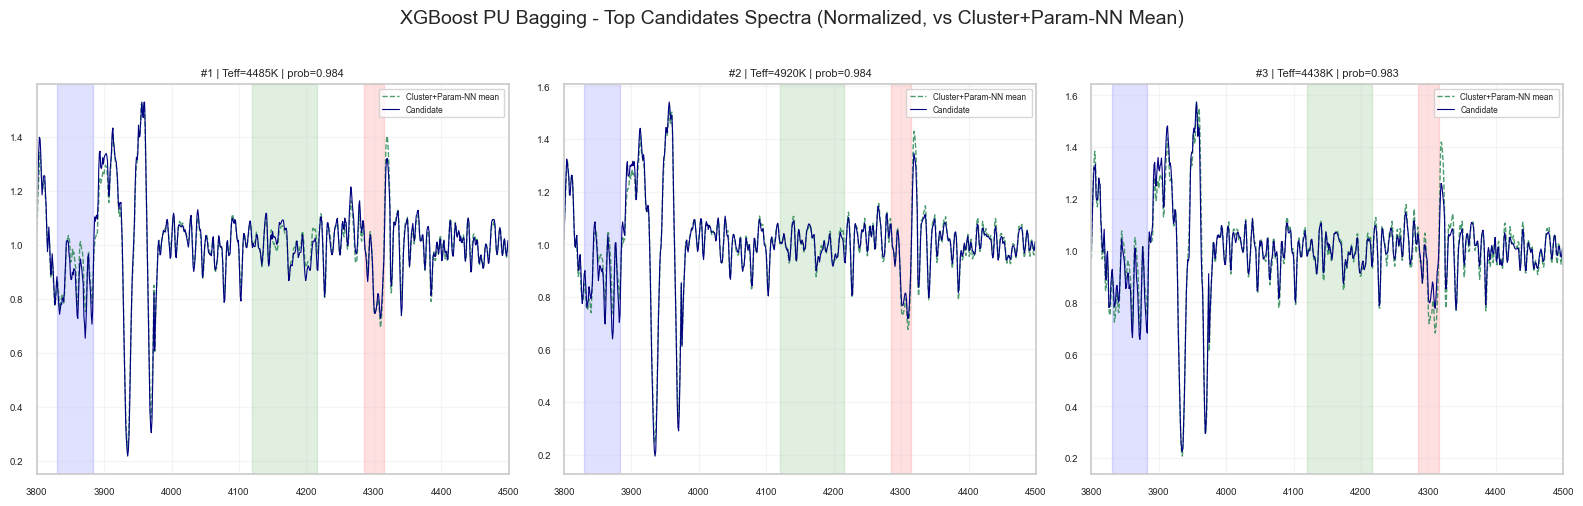

In [40]:
# 候选体光谱可视化（归一化光谱 + 掩盖聚类内三参数最近邻平均光谱对比）

top_n = 3

cand_vis = candidates.head(top_n)
cand_indices = cand_vis.index.values


fig, axes = plt.subplots(1, 3, figsize=(16,5 ))

axes = axes.flatten()


for i, idx in enumerate(cand_indices):

    ax = axes[i]

    flux = X_clean[idx]

    # 对比光谱：候选体所属掩盖聚类内、三参数(teff/logg/feh)最接近的恒星平均光谱。
    # 所选恒星同时满足"同一掩盖聚类"与"三参数接近"两个条件，即二者重合的部分，
    # 比全局三参数近邻更有说服力。
    param_mean = param_cluster_mean_spec(idx, stars_clean, Ps_all, X_clean)
    ax.plot(common_wave, param_mean, color='seagreen',
            linewidth=1.0, linestyle='--', alpha=0.85,
            label=f'Cluster+Param-NN mean ')

    # 候选体光谱
    ax.plot(common_wave, flux, color='navy', linewidth=0.8, label='Candidate')



    for l1, l2, c in [(3830, 3883, 'blue'), (4120, 4216, 'green'), (4285, 4315, 'red')]:

        ax.axvspan(l1, l2, alpha=0.12, color=c, zorder=0)



    prob = cand_vis.iloc[i]['xgb_pu_prob']

    teff = cand_vis.iloc[i]['teff']

    ax.set_title(f'#{i+1} | Teff={teff:.0f}K | prob={prob:.3f}', fontsize=8)

    ax.set_xlim(3800, 4500)

    ax.tick_params(labelsize=7)

    ax.grid(alpha=0.2)

    ax.legend(fontsize=6, loc='upper right')


for j in range(top_n, len(axes)):

    axes[j].axis('off')



fig.suptitle('XGBoost PU Bagging - Top Candidates Spectra (Normalized, vs Cluster+Param-NN Mean)', fontsize=14, y=1.01)

plt.tight_layout()

# plt.savefig(str(_PROJECT_ROOT / 'XGB/candidate_spectra_threshold.png'), dpi=150, bbox_inches='tight')

plt.show()

## 5. 候选体可视化：三参数分布

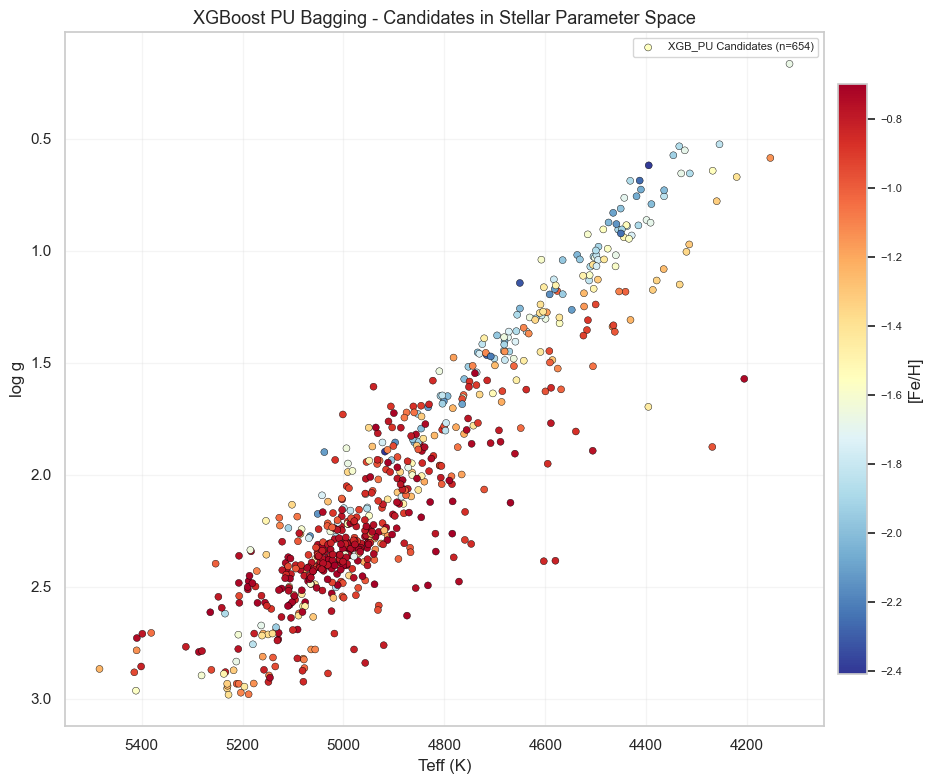

In [41]:
# Teff-logg-feh 三参数分布（仅绘制候选体，颜色表示FeH）

fig, ax = plt.subplots(figsize=(10, 8))

# Top candidates - color by FeH
top_n_plot =len(candidates)
cand_plot = candidates.head(top_n_plot)
sc = ax.scatter(cand_plot['teff'], cand_plot['logg'],
                s=25, c=cand_plot['feh'], cmap='RdYlBu_r',
                edgecolors='black', linewidth=0.3,
                label=f'XGB_PU Candidates (n={len(cand_plot)})', zorder=2)

cbar = plt.colorbar(sc, ax=ax, label='[Fe/H]', shrink=0.85, pad=0.015)
cbar.ax.tick_params(labelsize=8)

ax.set_xlabel('Teff (K)')
ax.set_ylabel('log g')
ax.invert_xaxis()
ax.invert_yaxis()
ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.2)
ax.set_title('XGBoost PU Bagging - Candidates in Stellar Parameter Space', fontsize=13)

plt.tight_layout()
plt.savefig(str(_PROJECT_ROOT / 'XGB/param_distribution_threshold.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. 导出高置信度候选体（已知CN星标定阈值）

In [44]:
# 导出结果

out_cols = ['uid', 'ra', 'dec', 'teff', 'logg', 'feh', 'label', 'snru',
            'xgb_pu_prob', 'xgb_pu_std', 'masked_cluster_id']
out_cols = [c for c in out_cols if c in candidates.columns]

out_df = candidates[out_cols].copy()  # 阈值筛选后的所有候选体
outpath = str(_PROJECT_ROOT / 'PhaseSummary/03_ML_XGB/XGB_PU_candidates_threshold.csv')
out_df.to_csv(outpath, index=False)

print(f"候选体已导出: {outpath}")
print(f"筛选阈值 prob_threshold = {prob_threshold:.4f}  (保留~{(1-recall_quantile)*100:.0f}%已知CN星)")
print(f"候选体统计 (共 {len(out_df)} 颗):")
print(f"  prob > 0.5: {(out_df['xgb_pu_prob'] > 0.5).sum()}")
print(f"  prob > 0.7: {(out_df['xgb_pu_prob'] > 0.7).sum()}")

候选体已导出: d:\资料\2026大创\Lamost\PhaseSummary\03_ML_XGB\XGB_PU_candidates_threshold.csv
筛选阈值 prob_threshold = 0.6747  (保留~95%已知CN星)
候选体统计 (共 654 颗):
  prob > 0.5: 654
  prob > 0.7: 554


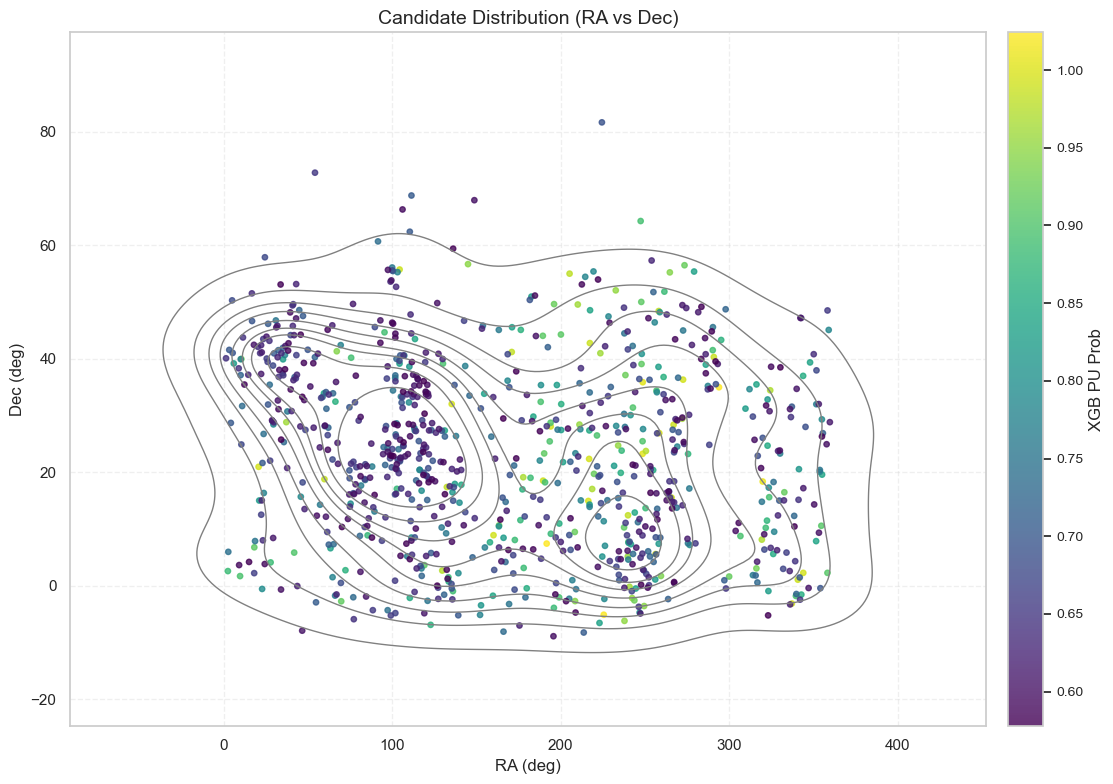

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# 1. 散点：用 c= 传数值，拿到 sc 对象直接绑定 colorbar
sc = ax.scatter(
    out_df['ra'],
    out_df['dec'],
    c=out_df['xgb_pu_prob'],
    cmap='viridis',
    s=15,
    alpha=0.8,
    edgecolors=None,          # 去掉点边框（注意是 edgecolors）
)

# 2. KDE 等密度线：用单一灰色，不参与色彩映射
sns.kdeplot(
    data=out_df,
    x='ra',
    y='dec',
    levels=10,
    color='gray',             # 单一颜色，不要 cmap
    linewidths=1.0,
    fill=False,
    ax=ax,
)

# 3. 只加一个 colorbar，对应散点的概率值
cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label('XGB PU Prob', fontsize=12)
cbar.ax.tick_params(labelsize=10)

ax.set_xlabel('RA (deg)', fontsize=12)
ax.set_ylabel('Dec (deg)', fontsize=12)
ax.set_title('Candidate Distribution (RA vs Dec)', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


## 7. 结论



**XGBoost PU Bagging 核心发现：**



1. **PU Bagging在原始光谱上表现最佳**：700维光谱直接输入，无需特征工程，ROC-AUC > 0.95

2. **优于9-D物理特征**：原始光谱比手工设计的CN/CH指数包含更丰富信息

3. **已知CN星标定阈值**：用已知CN星概率的低分位（保留~90%）标定候选阈值，物理可解释

4. **稳定性好**：T=500次Bagging的平均标准差 < 0.05，概率估计稳健